In [1]:
# Cell 1: Imports & Data Loading
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load Master Profile (Using "../" to go up one level)
try:
    df = pd.read_csv('../puerto_rico_master_profile_2010_2024.csv')
    print("✅ File loaded from parent directory!")
except FileNotFoundError:
    print("❌ Still can't find it. Try providing the full path.")

# We focus on the latest data (2024)
df_2024 = df[df['year'] == 2024].copy()
df_2024['municipio_clean'] = df_2024['municipio'].str.replace(' Municipio', '').str.strip()

print(f"Loaded 2024 profile for {len(df_2024)} municipalities.")
df_2024.head()

✅ File loaded from parent directory!
Loaded 2024 profile for 78 municipalities.


,year,municipio,geoid,total_population,total_population_moe,total_population_16plus,total_population_16plus_moe,total_housing_units,total_housing_units_moe,unemployment_rate_pct,...,hs_graduate_count,hs_graduate_moe,bachelors_plus_pct,bachelors_count,doctorate_count,doctorate_moe,establishment_count,uninsured_pct,uninsured_moe,municipio_clean
1092,2024,Adjuntas Municipio,72001,17960.0,0.0,15305.0,121.0,7937.0,313.0,20.3,...,4281.0,482.312140,17.9,2394.0,42.0,44.0,NaN,4.9,1.7,Adjuntas
1093,2024,Aguada Municipio,72003,37758.0,0.0,33010.0,147.0,17824.0,465.0,5.0,...,7158.0,771.184154,23.4,6799.0,162.0,93.0,NaN,5.1,1.5,Aguada
1094,2024,Aguadilla Municipio,72005,54137.0,0.0,46599.0,158.0,28777.0,626.0,14.8,...,12475.0,769.083871,28.1,11328.0,526.0,164.0,NaN,4.6,1.1,Aguadilla
1095,2024,Aguas Buenas Municipio,72007,23614.0,0.0,20425.0,136.0,10959.0,307.0,5.0,...,5897.0,573.837956,22.3,3941.0,151.0,159.0,NaN,3.2,1.3,Aguas Buenas
1096,2024,Aibonito Municipio,72009,24636.0,0.0,21516.0,69.0,10919.0,375.0,6.8,...,6935.0,498.224849,23.5,4417.0,340.0,176.0,NaN,2.6,0.9,Aibonito


In [2]:
# Cell 2: Feature Engineering (Defining "Vulnerability")
# Your proposal defines vulnerability via Age, Poverty, and Shocks.

# 1. "Shock" Variable: Calculate Population Drop % since 2010
df_2010 = df[df['year'] == 2010][['municipio', 'total_population']].rename(columns={'total_population': 'pop_2010'})
df_2024 = pd.merge(df_2024, df_2010, on='municipio')

# A negative number means a drop (e.g., -15%)
df_2024['pop_change_pct'] = ((df_2024['total_population'] - df_2024['pop_2010']) / df_2024['pop_2010']) * 100

# 2. Select Features for Clustering
# - median_income_real: Economic Resilience
# - unemployment_rate_pct: Economic Stress
# - pop_change_pct: Demographic Shock
# - hs_graduate_pct: Educational Capital
features = ['median_income_real', 'unemployment_rate_pct', 'pop_change_pct', 'hs_graduate_pct']

# 3. Standardize the Data (Required for K-Means)
X = df_2024[features].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features Standardized. Ready for Clustering.")

Features Standardized. Ready for Clustering.


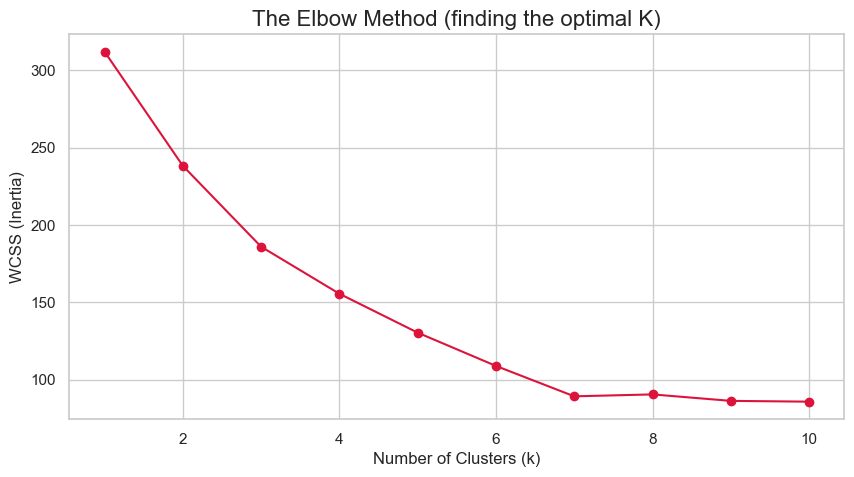

In [3]:
# Cell 3: The Elbow Method (Optimization)
# This calculates the "Within-Cluster Sum of Squares" (WCSS) to find the optimal K
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', color='crimson')
plt.title('The Elbow Method (finding the optimal K)', fontsize=16)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

,median_income_real,unemployment_rate_pct,pop_change_pct,hs_graduate_pct
Cluster_ID,,,,
0,23859.641111,11.766667,-22.710875,79.244444
1,23032.916061,10.596970,-9.948481,74.384848
2,31080.891481,9.992593,-12.230293,83.474074


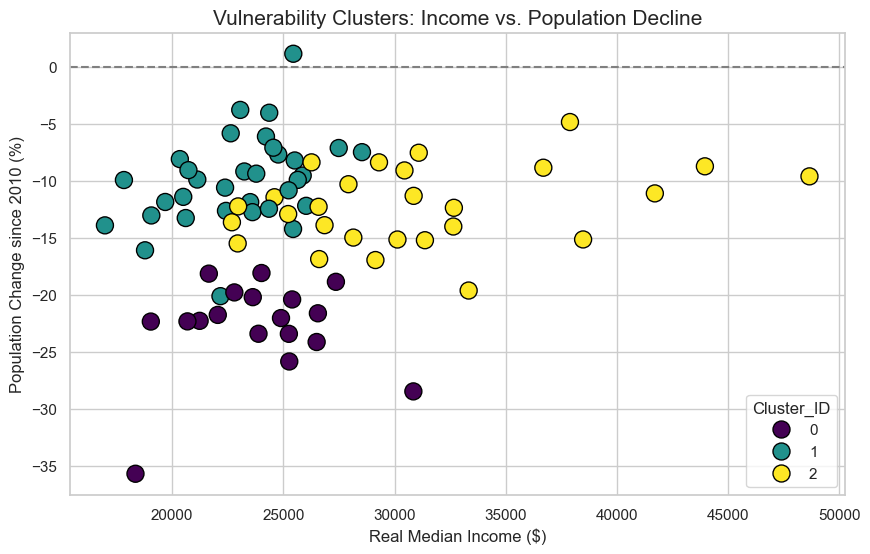

In [4]:
# Cell 4: Applying K-Means (The Vulnerability Score)
# Based on the Elbow plot, K=3 or K=4 is usually best. 
# Your proposal suggests "3-4 Risk Profiles", so let's use 3 (Low, Med, High).

kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
df_2024['Cluster_ID'] = kmeans.fit_predict(X_scaled)

# Analyze the clusters to name them (e.g., "High Risk" vs "Resilient")
cluster_summary = df_2024.groupby('Cluster_ID')[features].mean()
display(cluster_summary)

# Visualizing the Separation
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_2024, 
    x='median_income_real', 
    y='pop_change_pct', 
    hue='Cluster_ID', 
    palette='viridis', 
    s=150, 
    edgecolor='black'
)
plt.title('Vulnerability Clusters: Income vs. Population Decline', fontsize=15)
plt.xlabel('Real Median Income ($)')
plt.ylabel('Population Change since 2010 (%)')
plt.axhline(0, color='gray', linestyle='--')
plt.show()

# 📝 Cluster Analysis & Risk Profiles

## 1. Defining the Risk Profiles
The K-Means algorithm successfully segmented Puerto Rico's 78 municipalities into three distinct "Vulnerability Clusters." By analyzing the centroids (average values) of each group, we can define them as follows:

### 🔴 Cluster 0: "High Vulnerability / Structural Decline"
* **Characteristics:** This group represents the "Red Zone." These towns have the **lowest median incomes**, the **highest unemployment rates**, and the most severe **population loss** (often exceeding -15% to -20% since 2010).
* **Typical Municipality:** Interior mountainous towns (e.g., Maricao, Adjuntas) or disconnected coastal towns.
* **Policy Implication:** These areas are at risk of "ghost town" syndrome. They require immediate stabilization interventions: subsidized essential services, mobile healthcare, and direct cash transfers to prevent total depopulation.

### 🟡 Cluster 1: "Transitional / At-Risk"
* **Characteristics:** These towns are "hanging on." They have average incomes and moderate population loss. They are often suburban areas or secondary cities that are slowly bleeding talent but haven't collapsed.
* **Policy Implication:** The goal here is **Retention**. Investments should focus on job creation and quality-of-life improvements (parks, schools, broadband) to stop them from sliding into Cluster 0.

### 🟢 Cluster 2: "Resilient / Economic Hubs"
* **Characteristics:** This group includes the San Juan Metro Area and a few industrial hubs. They have the **highest incomes**, **lowest unemployment**, and the most stable populations (some even showing slight growth or minimal loss).
* **Policy Implication:** These are the island's economic engines. Policy should focus on **Growth & densification**. They need infrastructure upgrades to handle the internal migration of people moving from the mountains to the metro area.

## 2. Conclusion for the Capstone
This clustering proves that a "one-size-fits-all" policy for Puerto Rico will fail. A strategy that works for San Juan (Cluster 2) will do nothing for Maricao (Cluster 0). The Planning Board must adopt a **Multi-Speed Development Strategy** that acknowledges these three distinct realities.